# Infer a Kd from flow data for individual clones (not libraries)

This notebook requires two input files (and the flow cytometry data):
- a run-list which specifies the antibody and antigen that are being tested, along with the flow cytometry data directory
- a concentrations list which specifies the concentrations used (in -log10(Molar)), along with 'well' assignments for looking up the flow cytometry data (we use a 96-well format for making these measurements, so the well numbers are automatically output when we export the flow cytometry fcs files to csvs)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import collections
import glob
import scipy.optimize
import scipy.stats

In [2]:
#get run list
run_list = pd.read_csv('run-list.csv')
run_list = run_list.dropna(axis=0, how='any')  # drop columns with any NaN values
run_list['replicate'] = run_list['replicate'].astype(int)
run_list.head()

,directory,row,shortname,antigen,replicate
0,flow_data/omi32-germline_ba4_r1,E,Omi32,BA4,1
1,flow_data/omi32-germline_ba4_r2,E,Omi32,BA4,2
2,flow_data/omi32-germline_ba4_r1,A,Germline,BA4,1
3,flow_data/omi32-germline_ba4_r2,A,Germline,BA4,2


In [3]:
#get antigen concentrations
concentrations_list = pd.read_csv('concentrations-list.csv', index_col=[0])
cols = concentrations_list.index
concentrations_list

,BA4
well column,
1,6.0
2,7.0
3,8.0
4,9.0
5,10.0
6,10.5
7,14.0


In [4]:
# define functions for assigning csv to each mutant
def get_files(run_id):
    run_row = run_list.loc[run_id, :]
    wells = ['%c%02d' % (run_row['row'], i) for i in range(1, len(concentrations_list)+1)]

    def get_filename(well):
        search = os.path.join(run_row['directory'], f'*{well}*')
        filenames = glob.glob(search)
        if len(filenames) != 1:
            print(search, filenames)
            raise Exception(well)
        return filenames[0]

    return [pd.read_csv(get_filename(well)) for well in wells]


# #pin raw values (not log-transformed yet) to a safe detection threshold within linear detector range (based on average CST settings provided by UCSF Flow Core)
PIN_FLOOR = 100.0  # raw fluorescence floor; log10 floor = 2

def pin_fluor(run_id, floor=PIN_FLOOR, col='585/15 YG E-A'):
    run = get_files(run_id)

    for df in run:
        pe = df[col].astype(float).to_numpy()
        pe_pinned = np.maximum(pe, floor)
        df['PE_pinned'] = pe_pinned
        df['log_PE'] = np.log10(pe_pinned)

    run_row = run_list.loc[run_id, :]
    # optional: report how many values were pinned
    n_total = sum(len(df) for df in run)
    n_pinned = sum((df['PE_pinned'] == floor).sum() for df in run)
    print(run_row['shortname'], run_row['antigen'], f"pinned {n_pinned}/{n_total} < {floor}", sep='\t')

    return run


print('name', 'antigen', 'pin_stats', sep='\t')
runs = [pin_fluor(run_id) for run_id in run_list.index]
print(runs)


name	antigen	pin_stats
Omi32	BA4	pinned 9882/60908 < 100.0
Omi32	BA4	pinned 10159/70123 < 100.0
Germline	BA4	pinned 28042/61174 < 100.0
Germline	BA4	pinned 39072/68476 < 100.0
[[              FSC-A     FSC-H          FSC-W          SSC-A    SSC-H  \
0     143477.375000   88973.0  105683.007812   62868.718750  50624.0   
1     133960.078125   82003.0  107059.593750   57406.960938  46823.0   
2     194124.156250  114459.0  111150.015625  102430.437500  81327.0   
3     168410.187500  101711.0  108512.640625  159401.515625  82783.0   
4     183767.875000  110699.0  108794.226562   93560.523438  73019.0   
...             ...       ...            ...            ...      ...   
9980  132952.953125   80490.0  108252.015625   60818.519531  51454.0   
9981  140414.093750  100450.0   91609.539062   54376.878906  46822.0   
9982  107476.164062   71913.0   97945.546875   63989.359375  53268.0   
9983  144252.046875   88590.0  106712.968750   67951.039062  58570.0   
9984  117594.664062   73846.0 

## Fit fluorescence vs. [antigen] to get Kd

In [20]:
#https://elifesciences.org/articles/23156#s4

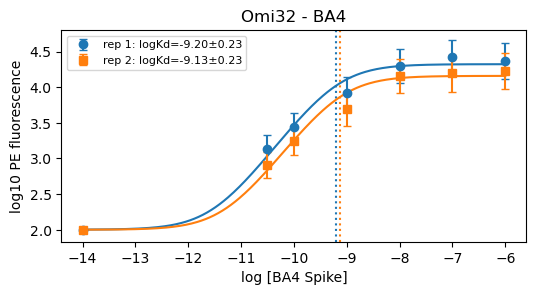

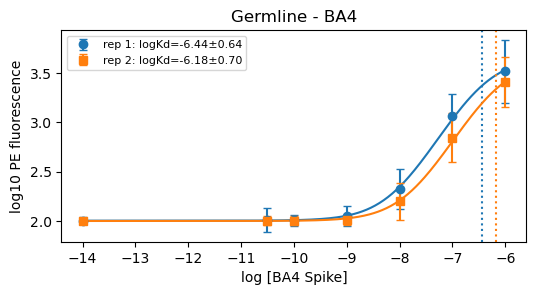

Done. Wrote KD/KD_err back into run_list and saved one PDF per shortname.


In [6]:
def sigmoid(c, Kd, A, B):
    return np.log10(A * (10**np.float64(c) / ((10**np.float64(c)) + (10**np.float64(Kd)))) + B)

def rms(y, yfit):
    return np.sqrt(np.sum((y - yfit)**2))

# init output columns
n_runs = run_list.shape[0]
run_list['KD'] = np.zeros(n_runs)
run_list['KD_err'] = np.zeros(n_runs)

# map run_id -> run data (1 dataframe per concentration)
run_by_id = {run_id: runs[i] for i, run_id in enumerate(run_list.index)}

# replicate styling (extend if you have >2 reps)
rep_colors = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd",
}
rep_markers = {1: "o", 2: "s", 3: "^", 4: "D", 5: "v"}

# plot one figure per set of antibody replicates (by shortname), overlay replicates
for shortname, grp in run_list.groupby('shortname', sort=False):

    # if a shortname spans multiple antigens, split further
    for antigen, grp2 in grp.groupby('antigen', sort=False):

        plt.figure(figsize=(6, 2.75))

        # concentrations for this antigen
        concs = (-concentrations_list[antigen]).copy()
        concs_plot = np.linspace(concs.min(), concs.max(), 300)

        # fit + plot each replicate
        for _, row in grp2.sort_values('replicate').iterrows():
            run_id = row.name  # index of run_list
            run = run_by_id[run_id]
            rep = int(row['replicate'])

            mean_log_fluor = [df['log_PE'].mean() for df in run]
            std_log_fluor  = [df['log_PE'].std()  for df in run]

            # curve_fit settings
            popt, pcov = scipy.optimize.curve_fit(
                sigmoid,
                concs,
                mean_log_fluor,
                p0=[(-9), 10**4, 10**2],
                sigma=std_log_fluor,
                absolute_sigma=True,
                bounds=[((-14), 1, 1), ((-5), 10**5, 10**5)],
                maxfev=400000
            )

            logKd = popt[0]
            logKd_err = float(np.sqrt(pcov[0][0])) if pcov.shape == (3,3) else np.nan

            # store results back into run_list row
            run_list.loc[run_id, 'KD'] = logKd
            run_list.loc[run_id, 'KD_err'] = logKd_err

            color = rep_colors.get(rep, "black")
            marker = rep_markers.get(rep, "o")

            plt.errorbar(
                concs, mean_log_fluor, yerr=std_log_fluor,
                fmt=marker, capsize=3, color=color,
                label=f"rep {rep}: logKd={logKd:.2f}±{logKd_err:.2f}"
            )
            plt.plot(concs_plot, sigmoid(concs_plot, *popt), color=color)
            plt.axvline(logKd, linestyle=":", color=color)

        plt.xlabel(f'log [{antigen} Spike]')
        plt.ylabel('log10 PE fluorescence')
        plt.legend(fontsize=8, loc='upper left')
        plt.title(f'{shortname} - {antigen}')
        plt.grid(False)

        # save per shortname+antigen
        outname = f"{shortname}_{antigen}_replicates.pdf"
        outname_png = f"{shortname}_{antigen}_replicates.png"
        #plt.savefig(f'images/{outname}', format="pdf", bbox_inches="tight")
        plt.savefig(f'images/{outname_png}', format="png", bbox_inches="tight", dpi=150)
        plt.show()

print("Done. Wrote KD/KD_err back into run_list and saved one PDF per shortname.")
